# Supermarket Sales Analysis

This project analyzes a supermarket sales dataset in order to understand
customer behavior, sales patterns, and key factors influencing revenue.

The analysis follows a full data science workflow including:

• Data exploration and visualization  
• Statistical inference  
• Regression modeling  
• Model validation  
• Time series analysis  

The goal of this analysis is to extract meaningful business insights
that could help improve sales strategies and better understand
customer purchasing behavior.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")

## Load Dataset

In [2]:
sales = pd.read_csv("SuperMarketAnalysis.csv")

sales.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


## Dataset Overview

In [3]:
sales.shape

(1000, 17)

In [4]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [5]:
sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Unit price,1000.0,55.672130,26.494628,10.080000,32.875000,55.230000,77.935000,99.960000
Quantity,1000.0,5.510000,2.923431,1.000000,3.000000,5.000000,8.000000,10.000000
Tax 5%,1000.0,15.379369,11.708825,0.508500,5.924875,12.088000,22.445250,49.650000
Sales,1000.0,322.966749,245.885335,10.678500,124.422375,253.848000,471.350250,1042.650000
cogs,1000.0,307.587380,234.176510,10.170000,118.497500,241.760000,448.905000,993.000000
gross margin percentage,1000.0,4.761905,0.000000,4.761905,4.761905,4.761905,4.761905,4.761905
gross income,1000.0,15.379369,11.708825,0.508500,5.924875,12.088000,22.445250,49.650000
Rating,1000.0,6.972700,1.718580,4.000000,5.500000,7.000000,8.500000,10.000000


The dataset contains transaction-level supermarket sales data.
Each row represents a single purchase made by a customer.

The dataset includes information about:

• Customer demographics (Gender, Customer type)
• Purchase characteristics (Product line, Quantity, Unit price)
• Payment method
• Sales performance metrics (Sales, Gross income, Rating)

These variables allow us to explore purchasing behavior,
Sales drivers, and build predictive models.

## Missing Values

In [6]:
sales.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

The dataset does not contain missing values,
therefore no data imputation or removal was required.

# Exploratory Data Analysis (EDA)

]In this section we explore the supermarket dataset using
descriptive statistics and visualizations.

The goal of EDA is to understand:

• distribution of key numerical variables  
• differences between customer groups  
• product category behavior  
• relationships between sales drivers

## Sales Distribution

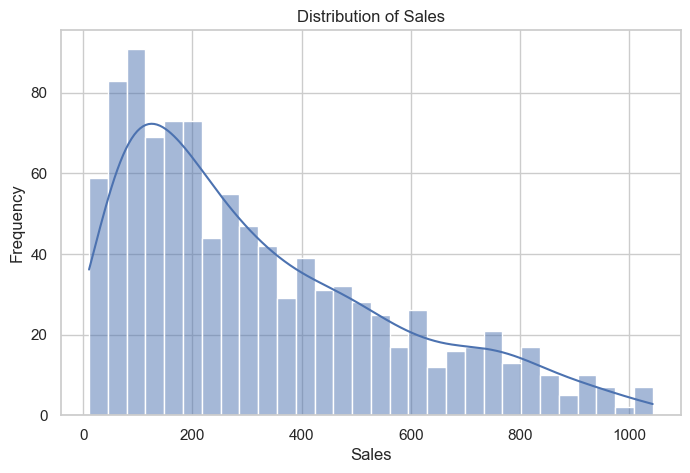

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(sales["Sales"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

The distribution of sales shows that most transactions
are relatively small while larger purchases occur less frequently.

This pattern is typical for retail environments where
customers often purchase a limited number of items per visit.

## Quantity Distribution

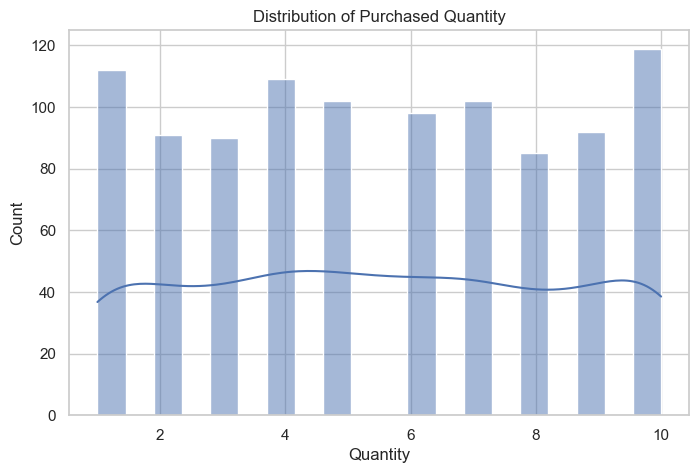

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(sales["Quantity"], bins=20, kde=True)

plt.title("Distribution of Purchased Quantity")

plt.show()

In [31]:
## Unit Price Distribution

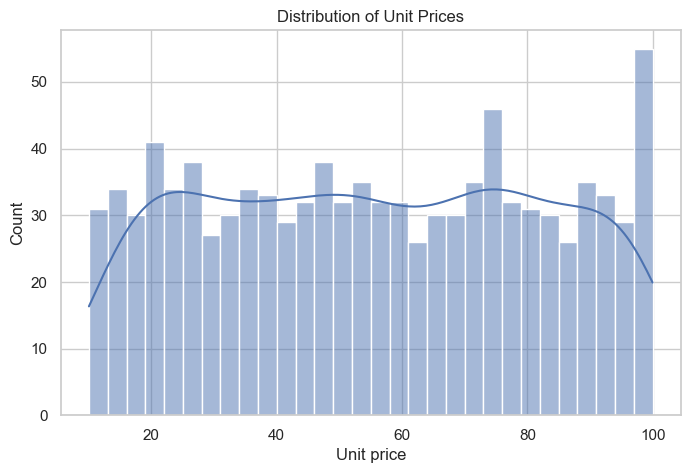

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(sales["Unit price"], bins=30, kde=True)

plt.title("Distribution of Unit Prices")

plt.show()

In [33]:
## Customer Ratings

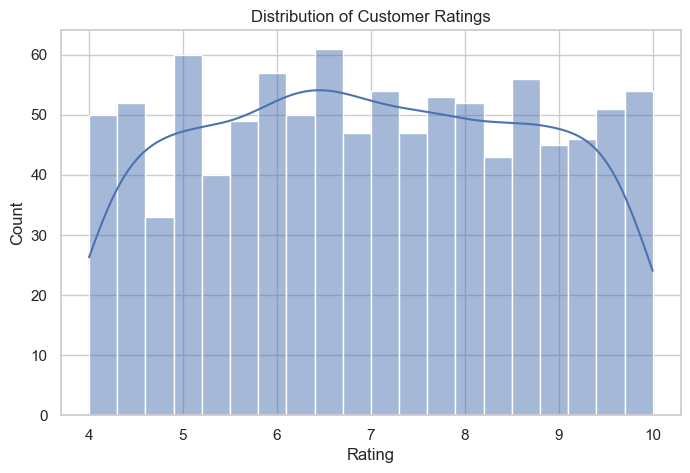

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(sales["Rating"], bins=20, kde=True)

plt.title("Distribution of Customer Ratings")

plt.show()

## Sales by Product Line

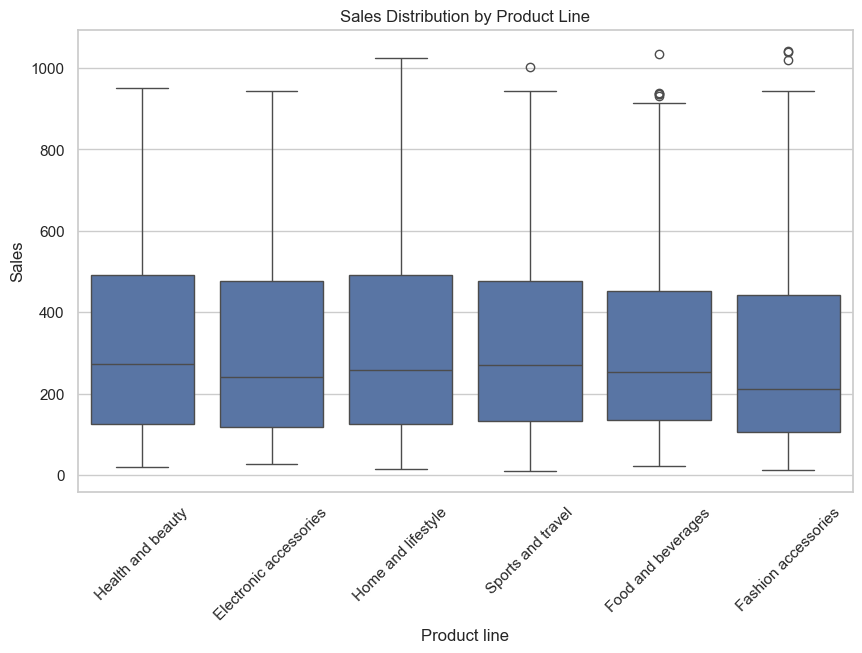

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Product line", y="Sales", data=sales)

plt.xticks(rotation=45)

plt.title("Sales Distribution by Product Line")

plt.show()

Different product categories show different sales distributions.

Some product lines generate larger transaction values,
indicating higher-priced items or larger purchase quantities.

## Sales by City

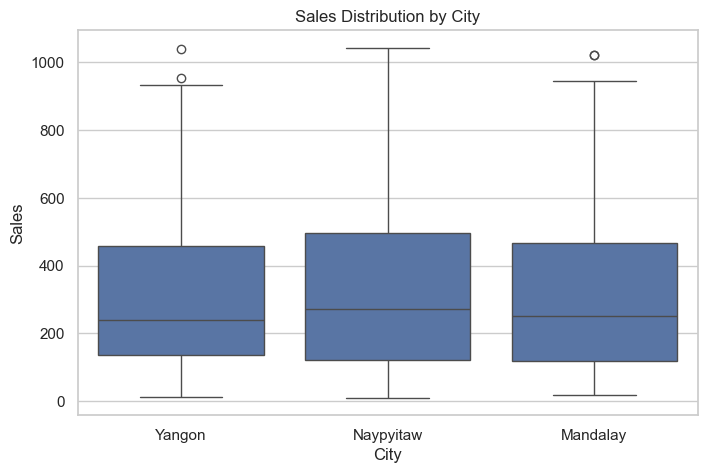

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(x="City", y="Sales", data=sales)

plt.title("Sales Distribution by City")

plt.show()

## Payment Methods

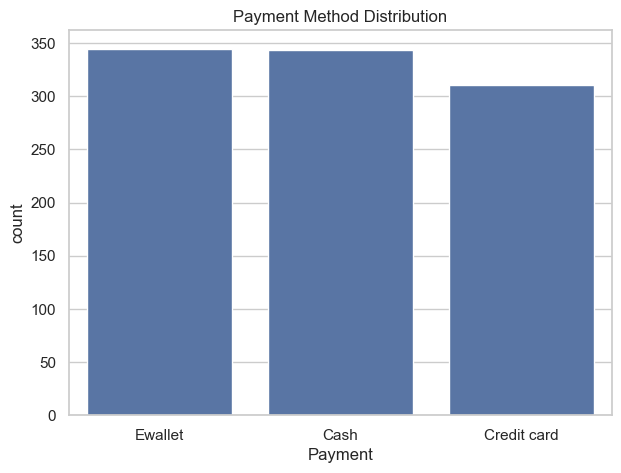

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(x="Payment", data=sales)

plt.title("Payment Method Distribution")

plt.show()

## Customer Type

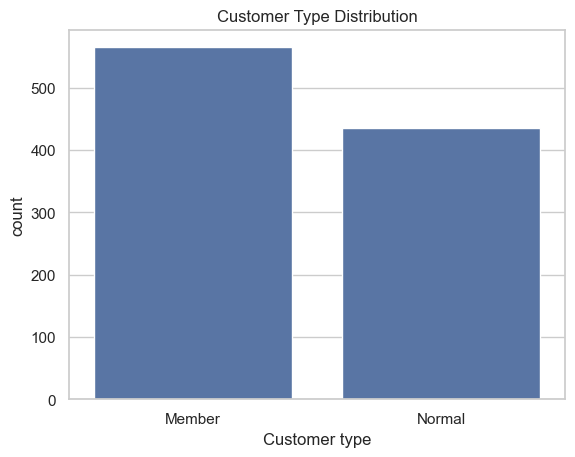

In [27]:
sns.countplot(x="Customer type", data=sales)

plt.title("Customer Type Distribution")

plt.show()

## Gender Distribution

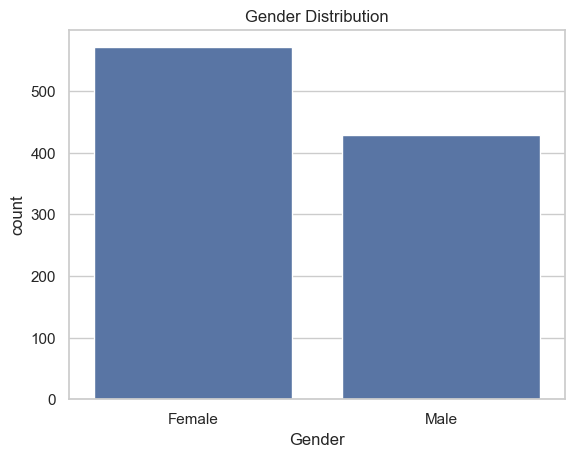

In [28]:
sns.countplot(x="Gender", data=sales)

plt.title("Gender Distribution")

plt.show()

## Correlation Matrix

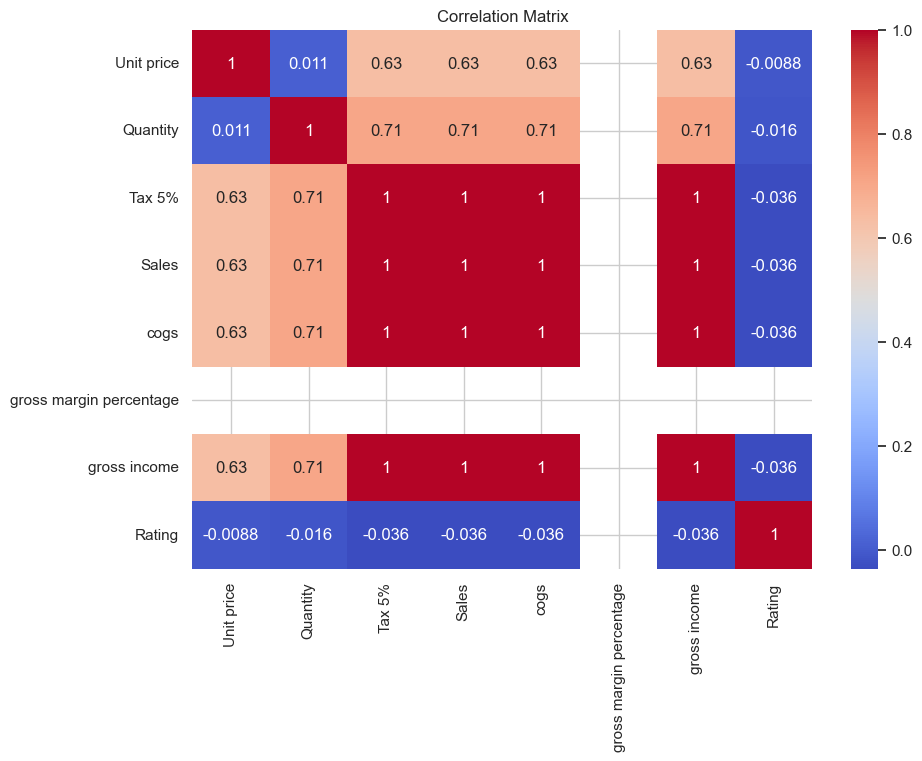

In [38]:
plt.figure(figsize=(10,7))

sns.heatmap(
    sales.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

The correlation matrix shows relationships between numerical variables in the dataset.
Perfect correlations are observed between Sales, COGS, Tax 5%, and Gross Income because these variables are mathematically derived from one another.
Additionally, the variable "gross margin percentage" has no variation in the dataset, resulting in undefined correlations (NaN values), which appear as blank spaces in the heatmap.
Sales also shows a strong positive correlation with Quantity and a moderate correlation with Unit Price, which is expected since total transaction value depends on both the number of items purchased and their price.

## Pairplot

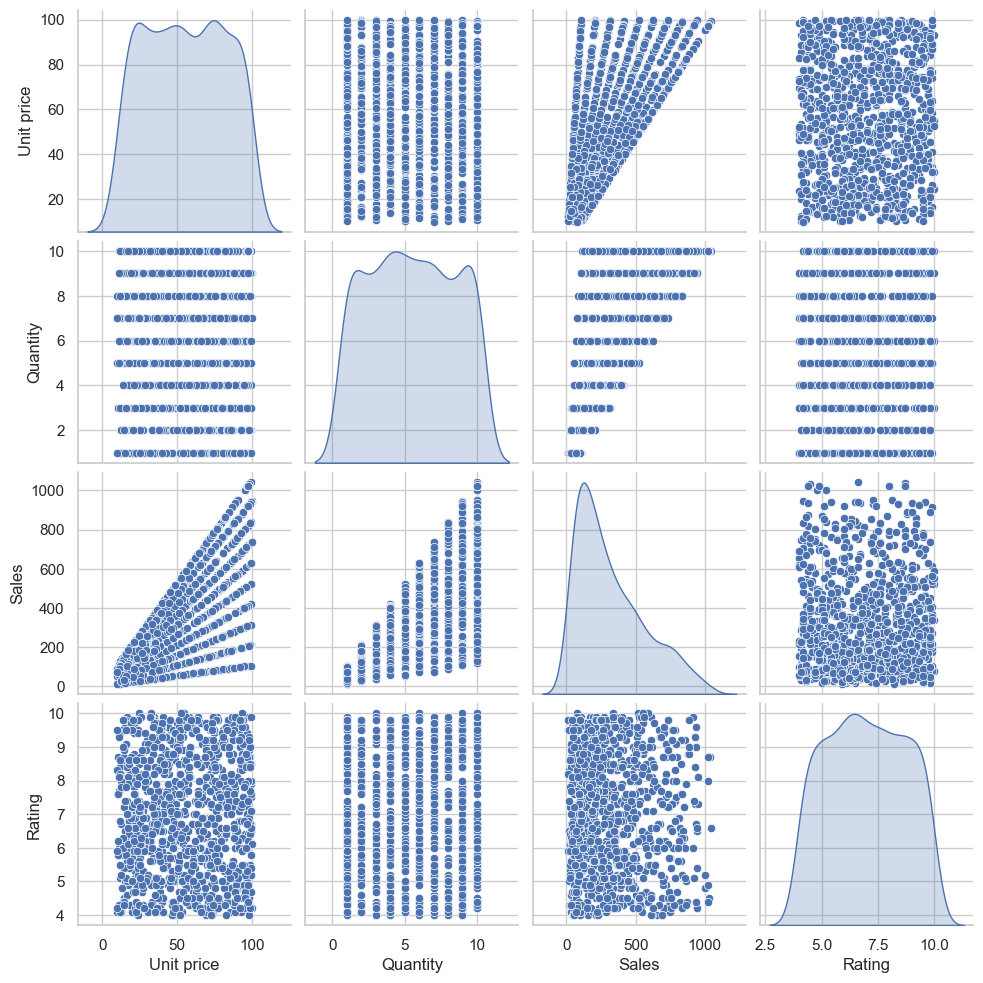

In [39]:
sns.pairplot(
    sales[["Unit price","Quantity","Sales","Rating"]],
    diag_kind="kde"
)

plt.show()

## Regression Plot

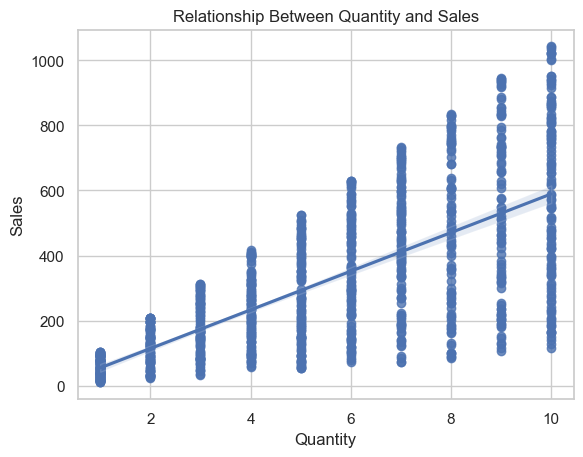

In [40]:
sns.regplot(x="Quantity", y="Sales", data=sales)

plt.title("Relationship Between Quantity and Sales")

plt.show()

# Statistical Inference

## Confidence Interval for Mean Sales

To estimate the true average transaction value,
we calculate a 95% confidence interval for the mean sales.

The confidence interval provides a range of values
within which the true population mean is likely to fall.

In [41]:
sales_mean = sales["Sales"].mean()
sales_std = sales["Sales"].std()
n = len(sales)

confidence = 0.95

ci = stats.t.interval(
    confidence,
    df=n-1,
    loc=sales_mean,
    scale=sales_std/np.sqrt(n)
)

ci

(np.float64(307.7084118264187), np.float64(338.2250861735813))

The calculated 95% confidence interval provides an estimated range
for the true average transaction value.

This means that if we repeatedly sampled similar datasets,
approximately 95% of the calculated intervals would contain
the true population mean sales value.

## Hypothesis Testing: Customer Type

We test whether the average sales value differs
between Member and Normal customers.

H0: There is no difference in mean sales between the groups.

Ha: Mean sales differ between Member and Normal customers.

In [42]:
members = sales[sales["Customer type"] == "Member"]["Sales"]
normal = sales[sales["Customer type"] == "Normal"]["Sales"]

t_stat, p_value = stats.ttest_ind(members, normal)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 1.8749713466198594
p-value: 0.06108851551521512


The t-test resulted in a p-value of 0.061.

Because the p-value is greater than the chosen significance
level of 0.05, we fail to reject the null hypothesis.

This suggests that there is no statistically significant
difference in average sales between Member and Normal customers
in this dataset.

Although the difference is not statistically significant
at the 5% level, the p-value is relatively close to the threshold,
which may suggest a weak tendency toward different spending behavior.
However, further data would be required to confirm such a pattern.

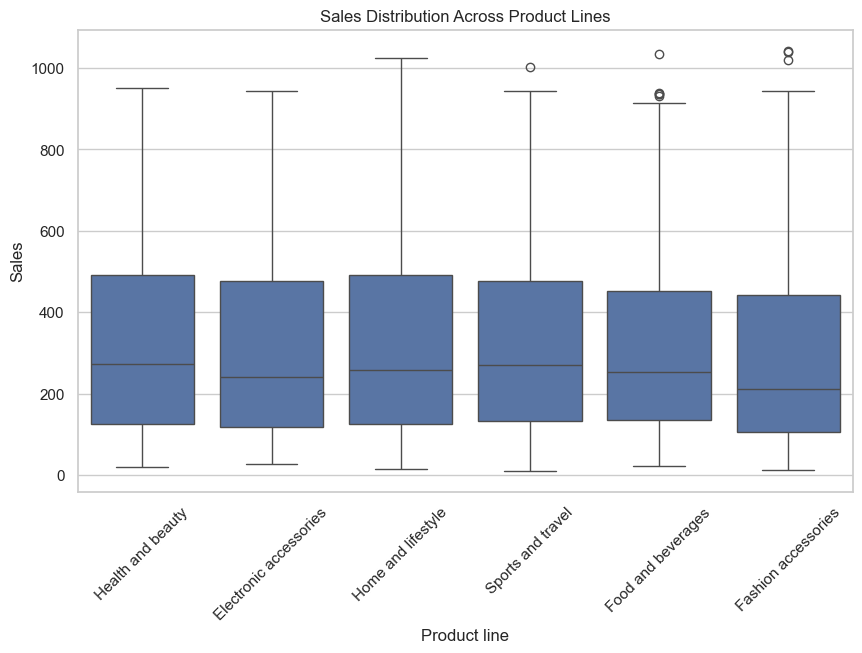

In [44]:
plt.figure(figsize=(10,6))

sns.boxplot(x="Product line", y="Sales", data=sales)

plt.xticks(rotation=45)
plt.title("Sales Distribution Across Product Lines")

plt.show()

The boxplot illustrates the distribution of sales across
different product categories and helps visualize potential
differences in average transaction values.

## ANOVA Test: Sales Across Product Lines

To determine whether average sales differ across product categories,
we perform a one-way ANOVA test.

H0: The mean sales are equal across all product lines.

Ha: At least one product line has a different mean sales value.

In [43]:
health_beauty = sales[sales["Product line"] == "Health and beauty"]["Sales"]
electronics = sales[sales["Product line"] == "Electronic accessories"]["Sales"]
home_lifestyle = sales[sales["Product line"] == "Home and lifestyle"]["Sales"]
sports = sales[sales["Product line"] == "Sports and travel"]["Sales"]
food = sales[sales["Product line"] == "Food and beverages"]["Sales"]
fashion = sales[sales["Product line"] == "Fashion accessories"]["Sales"]

f_stat, p_value = stats.f_oneway(
    health_beauty,
    electronics,
    home_lifestyle,
    sports,
    food,
    fashion
)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.3379647544618803
p-value: 0.8900398045913398


The ANOVA test resulted in a p-value greater than 0.05.

Therefore, we fail to reject the null hypothesis and conclude
that there is no statistically significant evidence that
average sales differ across product lines.